In [0]:
# Import important library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

### Read the input file and check the data dimension

In [0]:
from google.colab import drive
drive.mount('/content/gdrive')

Go to this URL in a browser: https://accounts.google.com/o/oauth2/auth?client_id=947318989803-6bn6qk8qdgf4n4g3pfee6491hc0brc4i.apps.googleusercontent.com&redirect_uri=urn%3Aietf%3Awg%3Aoauth%3A2.0%3Aoob&scope=email%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdocs.test%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive.photos.readonly%20https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fpeopleapi.readonly&response_type=code

Enter your authorization code:
··········
Mounted at /content/gdrive


In [0]:
# You can access from https://www.kaggle.com/uciml/german-credit
#Read input file and understand the data
# "default" is my dependent variable
import os
GPATH="/content/gdrive/My Drive/aiml/data/gl/"
os.listdir(GPATH)

['german_credit.csv', 'german_credit.gsheet']

In [0]:
df = pd.read_csv(GPATH+"german_credit.csv")
df.head()

,default,account_check_status,duration_in_month,credit_history,purpose,credit_amount,savings,present_emp_since,installment_as_income_perc,personal_status_sex,other_debtors,present_res_since,property,age,other_installment_plans,housing,credits_this_bank,job,people_under_maintenance,telephone,foreign_worker
0,0,< 0 DM,6,critical account/ other credits existing (not ...,domestic appliances,1169,unknown/ no savings account,.. >= 7 years,4,male : single,none,4,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes
1,1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,none,2,real estate,22,none,own,1,skilled employee / official,1,none,yes
2,0,no checking account,12,critical account/ other credits existing (not ...,(vacation - does not exist?),2096,... < 100 DM,4 <= ... < 7 years,2,male : single,none,3,real estate,49,none,own,1,unskilled - resident,2,none,yes
3,0,< 0 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,guarantor,4,if not A121 : building society savings agreeme...,45,none,for free,1,skilled employee / official,2,none,yes
4,1,< 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,none,4,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes


In [0]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
default                       1000 non-null int64
account_check_status          1000 non-null object
duration_in_month             1000 non-null int64
credit_history                1000 non-null object
purpose                       1000 non-null object
credit_amount                 1000 non-null int64
savings                       1000 non-null object
present_emp_since             1000 non-null object
installment_as_income_perc    1000 non-null int64
personal_status_sex           1000 non-null object
other_debtors                 1000 non-null object
present_res_since             1000 non-null int64
property                      1000 non-null object
age                           1000 non-null int64
other_installment_plans       1000 non-null object
housing                       1000 non-null object
credits_this_bank             1000 non-null int64
job                           1000

### Q1 Randomly select 50% data for this use case( 1 Marks)
###### Hint: Use train_test_split

In [0]:
X = df.drop("default",axis=1)
y = df["default"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.5, random_state=5)
X_train.shape

(500, 20)

In [0]:
# Lets build a Ensemble model but need to modify the dataset first


### Q2.Prepare the model data by converting non-numeric to dummy ( 1 Marks)
##### Hint: Use get_dummies

In [0]:
X_train1 = pd.get_dummies(X_train)

# Print Shape of model data
X_train1.shape

(500, 61)

### Check for highly correlated variables but don't required any treatment for this use case

In [0]:
X_train1.corr()

,duration_in_month,credit_amount,installment_as_income_perc,present_res_since,age,credits_this_bank,people_under_maintenance,account_check_status_0 <= ... < 200 DM,account_check_status_< 0 DM,account_check_status_>= 200 DM / salary assignments for at least 1 year,account_check_status_no checking account,credit_history_all credits at this bank paid back duly,credit_history_critical account/ other credits existing (not at this bank),credit_history_delay in paying off in the past,credit_history_existing credits paid back duly till now,credit_history_no credits taken/ all credits paid back duly,purpose_(vacation - does not exist?),purpose_business,purpose_car (new),purpose_car (used),purpose_domestic appliances,purpose_education,purpose_furniture/equipment,purpose_radio/television,purpose_repairs,purpose_retraining,savings_.. >= 1000 DM,savings_... < 100 DM,savings_100 <= ... < 500 DM,savings_500 <= ... < 1000 DM,savings_unknown/ no savings account,present_emp_since_.. >= 7 years,present_emp_since_... < 1 year,present_emp_since_1 <= ... < 4 years,present_emp_since_4 <= ... < 7 years,present_emp_since_unemployed,personal_status_sex_female : divorced/separated/married,personal_status_sex_male : divorced/separated,personal_status_sex_male : married/widowed,personal_status_sex_male : single,other_debtors_co-applicant,other_debtors_guarantor,other_debtors_none,property_if not A121 : building society savings agreement/ life insurance,"property_if not A121/A122 : car or other, not in attribute 6",property_real estate,property_unknown / no property,other_installment_plans_bank,other_installment_plans_none,other_installment_plans_stores,housing_for free,housing_own,housing_rent,job_management/ self-employed/ highly qualified employee/ officer,job_skilled employee / official,job_unemployed/ unskilled - non-resident,job_unskilled - resident,telephone_none,"telephone_yes, registered under the customers name",foreign_worker_no,foreign_worker_yes
duration_in_month,1.000000,0.654040,0.027427,0.031647,-0.028739,-0.012318,-0.088616,0.119097,-0.029266,-0.064492,-0.052160,0.010384,-0.095894,0.132989,-0.052697,0.163890,-0.013450,0.142405,-0.101268,0.162162,-0.022215,-0.019928,0.113923,-0.089504,-0.066668,-0.093316,-0.057130,-0.070710,0.114659,-0.043493,0.059778,-0.022239,-0.064343,0.019088,0.066323,0.001359,-0.064360,-0.001820,-0.058408,0.094448,0.073847,-0.004556,-0.041184,-0.059666,0.105960,-0.253202,0.234867,0.025993,-0.030418,0.013216,0.212120,-0.084126,-0.080277,0.175638,0.015190,-0.078192,-0.153405,-0.150134,0.150134,-0.166076,0.166076
credit_amount,0.654040,1.000000,-0.252611,0.047423,0.072994,0.054255,-0.047328,0.150565,-0.066205,-0.092983,-0.033688,-0.000453,-0.051913,0.092614,-0.067510,0.165012,-0.000660,0.101436,-0.027852,0.252401,-0.184189,-0.028970,0.228634,-0.060369,-0.068348,-0.077142,-0.057445,-0.013581,0.056787,-0.084976,0.061723,-0.011368,-0.057452,-0.043863,0.067150,0.094961,-0.093712,0.048780,-0.119556,0.132112,0.167696,-0.072195,-0.043134,-0.084422,0.079913,-0.263099,0.308138,0.047784,-0.047291,0.008403,0.263845,-0.163430,-0.028719,0.380871,-0.140484,-0.051385,-0.160887,-0.268796,0.268796,-0.089325,0.089325
installment_as_income_perc,0.027427,-0.252611,1.000000,0.048169,0.043957,-0.045177,-0.088518,-0.045938,0.045556,-0.086008,0.040933,0.046299,-0.001244,-0.035541,0.012395,-0.031736,-0.011405,-0.011911,-0.091408,-0.062970,0.185380,0.062893,-0.053455,-0.063214,-0.014564,0.025447,0.013606,-0.019450,-0.019109,-0.018301,0.046193,0.109057,-0.020022,-0.023650,-0.050172,-0.044726,-0.021945,-0.127454,0.007304,0.079421,-0.048721,-0.021759,0.047346,0.027272,0.022270,-0.055077,0.007294,-0.053770,0.005025,0.079319,0.010520,0.069805,-0.093490,0.050609,0.012890,-0.018606,-0.055904,-0.033286,0.033286,-0.096767,0.096767
present_res_since,0.031647,0.047423,0.048169,1.000000,0.268706,0.114518,0.048558,-0.058353,0.120912,-0.103208,-0.008819,0.027073,0.112964,-0.009637,-0.113639,0.004698,0.016965,-0.052922,0.016335,0.097566,-0.033447,0.026365,0.0634

### Drop the original variables which are converted to dummy

In [0]:
X_train2 = pd.get_dummies(X_train, drop_first=True)


### Q3 Split Train/Test data 70:30 ratio( 1 Marks)
##### Hint:from sklearn.model_selection import train_test_split

In [0]:
X = df.drop("default",axis=1)
y = df["default"]
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=5)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(700, 48) (300, 48) (700,) (300,)


### Q4 Build Random Forest Model( 1 Marks)
#### Hint:from sklearn.ensemble import RandomForestClassifier using n_jobs=2,n_estimators=500,criterion="entropy",random_state=9999

In [0]:
from sklearn.ensemble import RandomForestClassifier

Rf_model = RandomForestClassifier(n_jobs=2,n_estimators=500,criterion="entropy",random_state=9999)
Rf_model.fit(X_train, y_train)
y_predict=Rf_model.predict(X_test)

### Q5 Calculate Confusion Matrix and Accuracy score (1 Marks)
##### Hint: Use confusion_matrix and accuracy_score

In [0]:
from sklearn import metrics

cmatrix=metrics.confusion_matrix(y_true=y_test,y_pred=y_predict)
print("Confusion Matrix:\n",cmatrix)
acc=metrics.accuracy_score(y_true=y_test,y_pred=y_predict)
print("\nAccuracy:\n",acc)

Confusion Matrix:
 [[198  20]
 [ 51  31]]

Accuracy:
 0.7633333333333333


### Q6 Show the list of the features importance( 1 Marks)

In [0]:
print (pd.Series(Rf_model.feature_importances_,index = list(X)).sort_values(ascending=False))

credit_amount                                                                 0.116202
duration_in_month                                                             0.088174
age                                                                           0.086692
account_check_status_no checking account                                      0.060245
installment_as_income_perc                                                    0.040942
present_res_since                                                             0.038942
account_check_status_< 0 DM                                                   0.038154
credit_history_critical account/ other credits existing (not at this bank)    0.025119
credits_this_bank                                                             0.023519
other_installment_plans_none                                                  0.023376
telephone_yes, registered under the customers name                            0.020872
savings_... < 100 DM                       

### Q7 K-fold cross-validation( 2 Marks)
##### k-fold cross validation( without stratification)
##### Usually k is set as 10-20 in practical settings, depends on data set size

In [0]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

In [0]:
# Use below values
num_folds = 10
seed = 77

In [0]:
#Validate the Random Forest model build above using k fold

In [0]:
kfold = KFold(n_splits=num_folds,random_state=seed)
cv_results = cross_val_score(Rf_model, X, y, cv=kfold, scoring='accuracy')

In [0]:
#Calculate Mean score

In [0]:
print("Mean Score:", cv_results.mean())

Mean Score: 0.767


In [0]:
# Calculate score standard deviation using std()

In [0]:
print("Standard Deviation:", cv_results.std())

Standard Deviation: 0.057105166141076934


# Q8 Print the confusion matrix( 1 Marks)

In [0]:
Rf_model.fit(X_train, y_train)
y_predict=Rf_model.predict(X_test)
cmatrix=metrics.confusion_matrix(y_true=y_test,y_pred=y_predict)
cmatrix

array([[198,  20],
       [ 51,  31]])

# Q9.Classification accuracy: 
percentage of correct predictions and Calculate sensitivity (or True Positive Rate or Recall) and Precision.
( 1 Marks)

In [0]:
print("Accuracy:", (cmatrix[0,0]+cmatrix[1,1])/cmatrix.sum())

Accuracy: 0.7633333333333333


In [0]:
#recall: tp/(tp+fn)
print("Recall:",cmatrix[1,1]/(cmatrix[1,1]+cmatrix[1,0]))

#Precision:tp/(tp+fp)
print("Precision:",cmatrix[1,1]/(cmatrix[1,1]+cmatrix[0,1]))

Recall: 0.3780487804878049
Precision: 0.6078431372549019


# Q10.Plot Receiver Operating Characteristic (ROC) Curves( 1 Marks)

In [0]:
#Hint: Use roc_curve

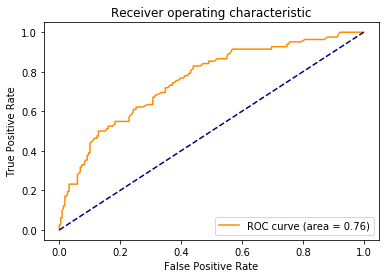

In [0]:
from sklearn.metrics import roc_curve, auc
Rf_model.fit(X_train, y_train)
y_predictProb = Rf_model.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_predictProb[::,1])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")

In [0]:
thresholds

array([1.792, 0.792, 0.772, 0.77 , 0.74 , 0.734, 0.702, 0.7  , 0.678,
       0.674, 0.67 , 0.662, 0.658, 0.654, 0.652, 0.642, 0.634, 0.596,
       0.594, 0.59 , 0.58 , 0.572, 0.568, 0.566, 0.546, 0.538, 0.534,
       0.53 , 0.524, 0.522, 0.51 , 0.502, 0.492, 0.49 , 0.484, 0.48 ,
       0.478, 0.474, 0.472, 0.46 , 0.458, 0.456, 0.454, 0.44 , 0.436,
       0.432, 0.428, 0.416, 0.41 , 0.408, 0.398, 0.39 , 0.38 , 0.378,
       0.372, 0.37 , 0.368, 0.366, 0.358, 0.354, 0.346, 0.344, 0.34 ,
       0.336, 0.33 , 0.328, 0.324, 0.322, 0.32 , 0.318, 0.314, 0.306,
       0.292, 0.288, 0.286, 0.282, 0.278, 0.274, 0.272, 0.27 , 0.268,
       0.26 , 0.258, 0.252, 0.25 , 0.244, 0.242, 0.24 , 0.236, 0.226,
       0.222, 0.22 , 0.218, 0.216, 0.214, 0.212, 0.206, 0.202, 0.2  ,
       0.19 , 0.186, 0.184, 0.182, 0.178, 0.174, 0.17 , 0.168, 0.166,
       0.162, 0.16 , 0.156, 0.154, 0.144, 0.14 , 0.138, 0.13 , 0.128,
       0.126, 0.124, 0.12 , 0.118, 0.116, 0.108, 0.106, 0.104, 0.102,
       0.098, 0.092,

ROC curve can help you to choose a threshold that balances sensitivity and specificity in a way that makes sense for your particular context

# Q11. Calculate AUC(the percentage of the ROC plot that is underneath the curve) - optional

### Bootstrapping ( Bonus)
##### Given a dataset of size n, a bootstrap sample is created by sampling n instances uniformly from the data (with/without replacement)
##### Create a model with each bootstrap sample and validate it with the test set
##### Final result is calculated by averaging the accuracy of models

In [0]:
# Number of iterations for bootstrapping
bootstrap_iteration = 10
accuracy = []

In [0]:
from sklearn.utils import resample
from sklearn.metrics import accuracy_score

for i in range(bootstrap_iteration):
    X_, y_ = resample(X_train, y_train)
    Rf_model.fit(X_, y_)
    y_pred = Rf_model.predict(X_test)
    
    acc = accuracy_score(y_pred, y_test)
    accuracy.append(acc)

In [0]:
accuracy = np.array(accuracy)
print('Accuracy Score')
print('Avearge: ', accuracy.mean())
print('Standard deviation: ', accuracy.std())

Accuracy Score
Avearge:  0.755
Standard deviation:  0.009339283817414602
